  Name  Math  Science
0    A    78       72
1    B    85       88
2    C    90       95
3    D    66       70
4    E    88       85
5    F    92       90
6    G    75       78
7    H    80       82
8    I    84       86
9    J    89       91
Mean: 82.7
Median: 84.5
Variance: 58.209999999999994
Standard Deviation: 7.629547824084989
Probability (Score > 80): 0.6


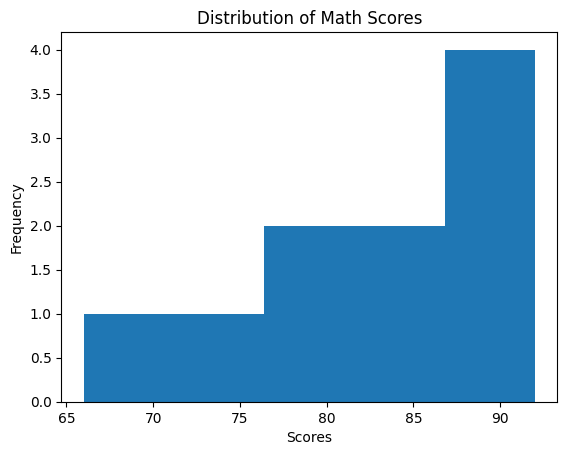

Mean: 82.7
Std Dev: 7.629547824084989


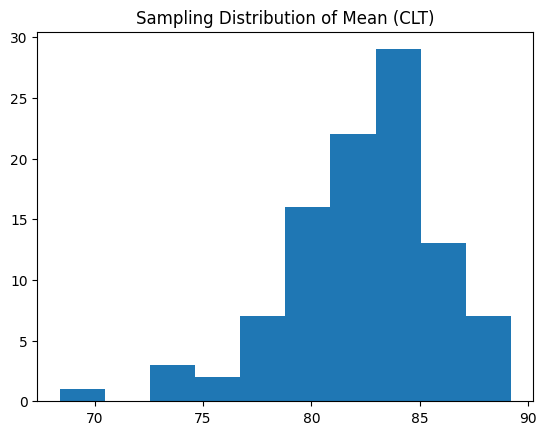

p-value: 0.7862832637920385
No significant difference
Chi-square p-value: 0.011412036386001662


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

data = {
    "Name": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"],
    "Math": [78, 85, 90, 66, 88, 92, 75, 80, 84, 89],
    "Science": [72, 88, 95, 70, 85, 90, 78, 82, 86, 91]
}

df = pd.DataFrame(data)

print(df)
# Basic Statistics
math_scores = df["Math"]

print("Mean:", np.mean(math_scores))
print("Median:", np.median(math_scores))
print("Variance:", np.var(math_scores))
print("Standard Deviation:", np.std(math_scores))

# Probability of scoring above 80 in Math
prob = np.sum(math_scores > 80) / len(math_scores)

print("Probability (Score > 80):", prob)

# 5. Distribution Visualization
plt.hist(math_scores, bins=5)
plt.title("Distribution of Math Scores")
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.show()

# 6. Identify Distribution (Check Mean & Shape)
print("Mean:", np.mean(math_scores))
print("Std Dev:", np.std(math_scores))

# 7. Sampling & CLT
sample_means = []

for i in range(100):
    sample = np.random.choice(math_scores, size=5)
    sample_means.append(np.mean(sample))

plt.hist(sample_means, bins=10)
plt.title("Sampling Distribution of Mean (CLT)")
plt.show()

t_stat, p_value = stats.ttest_ind(df["Math"], df["Science"])

print("p-value:", p_value)

# Interpretation
alpha = 0.05

if p_value < alpha:
    print("Significant difference between Math and Science scores")
else:
    print("No significant difference")

# Pass if score >= 75
math_pass = np.sum(df["Math"] >= 75)
math_fail = np.sum(df["Math"] < 75)

observed = np.array([math_pass, math_fail])
expected = np.array([len(df)/2, len(df)/2])

chi_stat, p_value = stats.chisquare(observed, expected)

print("Chi-square p-value:", p_value)